# Handwriting Recognition via ANN
This small notebook aims at solving the well-knows\n ANN demo: multiclass classification of hand-written digits, using the classic MNIST dataset.

## Dataset analisys and cleaning
The dataset was downloaded from kaggle.com. The training set consists of 60.000 28x28 greyscale images. The testing set is similar, but contains 10.000 images.
The original format is UBYTE-IDX3, and was parsed into an appropriate numpy array via a custom-made function available in ubyte_idx_reader.py.

In [29]:
#IMPORT DEPENDANCES
from DATA.ubyte_idx_reader import Mnistreader
import torch
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import random
import numpy as np
import torch.nn.functional as F
from time import time
import os


### Device check and selection

In [ ]:
#check for CUDA availability for Torch and check the correct device is selected
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
#DEBUG - force CPU usage
#device = "cpu"
print(f"Using {device} device")


Using npu device


### Random seed setting for reproducibility

In [31]:
#SEED SETTING
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
torch.cuda.manual_seed_all(GLOBAL_SEED)
generator = torch.Generator().manual_seed(GLOBAL_SEED)

## Pytorch wrappers & initialization
The Mnistreader custom class reads the files well, but Pytorch only speaks Tensors, Datasets and Dataloaders. Let's implement Dataset correctly in order to link Pytorch to our dataset:

In [32]:
from dataset import Dataset
#custom dataset class, implements the methods required by pytorch - moved in a separate file for parallization purposes
"""
class Dataset:

    def __init__(self, set_path=None, labels_path=None): #initializes the dataset instance with the actual data from the Mnistreader library
        self.data = Mnistreader(set_path).data
        self.labels = Mnistreader(labels_path).data
        
    def __len__(self):          #returns the size of the data
        return  len(self.data)
        
    def __getitem__(self, idx): #returns a single element in a (point, label) tuple, given the index
        return(torch.tensor(self.data[idx], dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long))
        #NB: if ANY feature processing was to be done, it should be done here on query, NOT on the entire dataset, to take advantage of asyncronous operations.

"""

'\nclass Dataset:\n\n    def __init__(self, set_path=None, labels_path=None): #initializes the dataset instance with the actual data from the Mnistreader library\n        self.data = Mnistreader(set_path).data\n        self.labels = Mnistreader(labels_path).data\n\n    def __len__(self):          #returns the size of the data\n        return  len(self.data)\n\n    def __getitem__(self, idx): #returns a single element in a (point, label) tuple, given the index\n        return(torch.tensor(self.data[idx], dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long))\n        #NB: if ANY feature processing was to be done, it should be done here on query, NOT on the entire dataset, to take advantage of asyncronous operations.\n\n'

## Hyperparameters
We define all the necessary parameters here, so it's easier to experiment:

In [33]:
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-3
NUM_WORKERS = 0 #number of data loading subprocesses. Small dataset, BP=0. If the dataset was larger, we could set this to a higher number to speed up data loading.

LRS_FACTOR = 0.5 #factor of learning rate to be reduced in case of validation loss plateau

LR_PATIENCE = 5    #consecutive epochs to wait before applying learning_rate*=LRS_FACTOR
ES_PATIENCE = 10   #consecutive epochs to wait before early stop the model on validation loss

L2_AMOUNT = 1e-4 #L2 regularization amount, applied as weight decay in the optimizer

MODEL_NAME = "LINEAR_MNIST"

We now need to create our Dataset combined with an instance of the Dataloader class to help us with batching, asyncronous loading of data into the VRAM and random shuffling:

_NB: Dataset class was moved to separate .py file due to windows' inability to multi-thread in .ipynb files._


In [34]:
#training set
train_set_path = "DATA/train-images.idx3-ubyte"
train_labels_path = "DATA/train-labels.idx1-ubyte"
train_d = Dataset(train_set_path, train_labels_path)


#validation set splitted from train_d
train_d, vali_d = torch.utils.data.random_split(dataset=train_d, lengths=[50000,10000], generator=generator)

train_dataloader = DataLoader(train_d, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
vali_dataloader = DataLoader(vali_d, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)

#test set
test_set_path = "DATA/t10k-images.idx3-ubyte"
test_set_labels = "DATA/t10k-labels.idx1-ubyte"

test_d = Dataset(test_set_path, test_set_labels)
test_dataloader = DataLoader(test_d, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)

## Neural Network instancing
In Pytorch, NNs are defined by subclassing nn.Module.

Layers are defined inside the constructor (__init__).

The forward() method is needed to define the feed operations: layer by layer, with appropriate non-linear functions. We will use the "vanilla" definition, and later use nn.Sequential to compact things up.

In [35]:
class NeuralNetwork(nn.Module):
    def __init__(self): #init contains the weights.
        super().__init__()

        self.flatten = nn.Flatten() #useful to have N-dim inputs flattened automatically during the forward pass
        #TODO convert in nn.Sequential to understand how it works
        self.l1 = nn.Linear(28*28,14*28)
        self.l2 = nn.Linear(14*28,14*14)
        self.l3 = nn.Linear(14*14, 7*14)
        self.l4 = nn.Linear(7*14, 7*7)
        self.l5 = nn.Linear(7*7,10)

    def forward(self, x):  #forward contains the operations to be performed on the instanced weights.
        #Operations need to be written IN ORDER.
        #forward needs to return logits, then other functions will use the appropriate loss.
        x = self.flatten(x) #flatten input
        x = self.l1(x)     #1st layer
        x = F.relu(x)       #act. function
        x = self.l2(x)     #...
        x = F.relu(x)
        x = self.l3(x)
        x = F.relu(x)
        x = self.l4(x)
        x = F.relu(x)
        x = self.l5(x)
        return x            #output

Let's instance the NN, load it into the GPU and see if the structure is the one we wanted:

In [36]:
model = NeuralNetwork().to(device) #instance the NN and load it into memory (preferably VRAM)

train = True
if(MODEL_NAME in os.listdir()):
    model.load_state_dict(torch.load(MODEL_NAME))
    train = False

print(model)

RuntimeError: Expected one of cpu, cuda, ipu, xpu, mkldnn, opengl, opencl, ideep, hip, ve, fpga, maia, xla, lazy, vulkan, mps, meta, hpu, mtia, privateuseone device type at start of device string: npu

Let's now define the loss and the optimizer. We'll use SGD for now, and move later to ADAM. 

A scheduler is added to allow for learning rate scheduling to optimize training based on epoch validation loss.

In [ ]:
loss_fn = nn.CrossEntropyLoss() #loss function for multi-class classification
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, weight_decay=L2_AMOUNT) #optimizer, with the model's parameters and a (fixed for now)learning rate
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=LRS_FACTOR,patience=LR_PATIENCE) #learning rate scheduler, to reduce the learning rate in case of validation loss plateau

## Training loop!
We now setup the training loop.'

LO LO GRA BA S!

logits -> loss -> grad reset -> backward -> step

In [ ]:
train_losses = []
val_losses = []

best_val_loss = float('inf') #initial best validation loss, used to save the best model during training
fedup_counter = 0

if train:
    train_start = time()
    for e in range(EPOCHS):
        epoch_start = time()

        epoch_train_loss,epoch_val_loss = 0,0

        #---TRAINING---

        for x,y in train_dataloader: #NB: the dataloader is an iterator, it will give us BATCH_SIZE number of elements each epoch.
            x = x.to(device)                #move x tensor to GPU
            y = y.to(device)                #move y tensor to GPU
            logits = model(x)               #forward pass
            loss = loss_fn(logits,y)        #loss evaluation
            epoch_train_loss+=loss.item()   #append loss actual number to log array
            optimizer.zero_grad()           #reset the gradients (needed)
            loss.backward()                 #start the pytorch backward pass
            optimizer.step()                #s = -a*(dL/dw), actual gradient step 
        train_losses.append(epoch_train_loss/len(train_dataloader)) #append to final loss array the average train loss for this epoch
        
        #---EVALUATION---
        model.eval()                        #set pytorch to eval mode - no dropout or batchnorm layer active. Useless here but good practice.
        with torch.no_grad():               #tell pytorch to not build computational graph for efficient backprop, unneedded in eval. with is used to avoid calculating gradients.
            for x, y in vali_dataloader:        #eval loop
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = loss_fn(logits,y)
                epoch_val_loss+=loss.item()
            val_losses.append(epoch_val_loss/len(vali_dataloader)) #append to final loss array the average validation loss for this epoch
            scheduler.step(val_losses[-1])  #update learning rate based on validation loss, based on criteria set in the above cell

        #EARLY STOPPING LOGIC
        if fedup_counter<ES_PATIENCE:          #if patience hasn't ended yet:          
            if val_losses[-1]>best_val_loss:    #if the model is not improving
                fedup_counter+=1                #increase angriness
            else:                           #else
                best_val_loss=val_losses[-1]    #update best loss
                torch.save(model.state_dict(), "LINEAR_MNIST.pth") #save best model yet
                fedup_counter = 0               #reset angriness counter
        else:
            print(" ".join(["EARLY STOPPING at epoch",str(e),"- model performance hasn't improved for",str(ES_PATIENCE),"EPOCHS"]))
            break

        model.train()   #undo model.eval()
        print("".join(['EPOCH ' ,str(e),"/",str(EPOCHS), ' LOSS: ', str('%.4f'%train_losses[-1]) , ' TIME: ', str('%.2f'%((time()-epoch_start))) , "sec" , ", LR:",str(optimizer.param_groups[0]['lr'])]))
    print("".join(["TOTAL TRAIN TIME: ",str('%.2f'%((time()-train_start)))," sec"]))
else:
    print("MODEL LOADED, SKIPPING TRAINING")


EPOCH 0/50 LOSS: 0.4148 TIME: 3.70sec, LR:0.001
EPOCH 1/50 LOSS: 0.1821 TIME: 3.59sec, LR:0.001
EPOCH 2/50 LOSS: 0.1347 TIME: 3.33sec, LR:0.001
EPOCH 3/50 LOSS: 0.1067 TIME: 4.45sec, LR:0.001
EPOCH 4/50 LOSS: 0.0873 TIME: 3.93sec, LR:0.001
EPOCH 5/50 LOSS: 0.0729 TIME: 3.80sec, LR:0.001
EPOCH 6/50 LOSS: 0.0617 TIME: 3.82sec, LR:0.001
EPOCH 7/50 LOSS: 0.0517 TIME: 3.79sec, LR:0.001
EPOCH 8/50 LOSS: 0.0442 TIME: 3.82sec, LR:0.001
EPOCH 9/50 LOSS: 0.0373 TIME: 3.73sec, LR:0.001
EPOCH 10/50 LOSS: 0.0318 TIME: 3.81sec, LR:0.001
EPOCH 11/50 LOSS: 0.0267 TIME: 4.05sec, LR:0.001
EPOCH 12/50 LOSS: 0.0228 TIME: 3.67sec, LR:0.001
EPOCH 13/50 LOSS: 0.0197 TIME: 3.63sec, LR:0.001
EPOCH 14/50 LOSS: 0.0165 TIME: 3.65sec, LR:0.001
EPOCH 15/50 LOSS: 0.0136 TIME: 3.62sec, LR:0.001
EPOCH 16/50 LOSS: 0.0115 TIME: 3.43sec, LR:0.001
EPOCH 17/50 LOSS: 0.0098 TIME: 3.70sec, LR:0.001
EPOCH 18/50 LOSS: 0.0085 TIME: 3.73sec, LR:0.001
EPOCH 19/50 LOSS: 0.0068 TIME: 3.74sec, LR:0.001
EPOCH 20/50 LOSS: 0.0060 TIME:

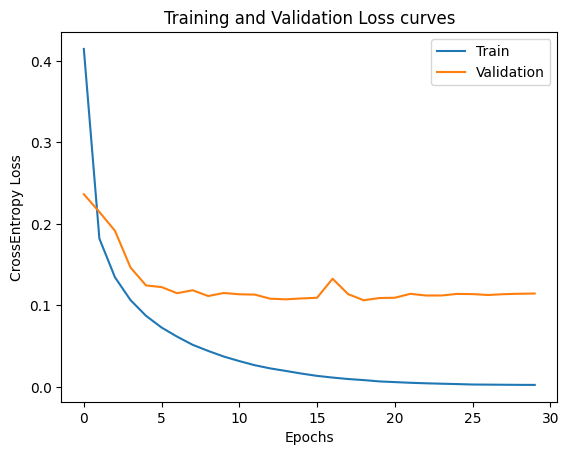

In [ ]:
plt.plot(train_losses)
plt.plot(val_losses)
plt.xlabel('Epochs')
plt.ylabel('CrossEntropy Loss')
plt.title('Training and Validation Loss curves')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
 #---EVALUATION AND LABELING---

y_pred = []         #predicted labels array, useful for later model evaluation
y_true = []

for x, y in vali_dataloader:            #eval loop: for each point in the eval set
    x, y = x.to(device), y.to(device)   #send tensors to the GPU
    logits = model(x)                   #forward pass, obtain logits
    y_pred.append(torch.argmax(logits,1))   #use torch.argmax to extract prediction from the logits tensor in a vectorized way
    y_true.append(y)
    #print(torch.argmax(logits,1))
    #print(y_true)
    #break
#IMPORTANT: the tensors need to be moved back to the CPU in order to evaluate metrics using scikitlearn/numpy
y_pred = (torch.cat(y_pred).cpu()).numpy()
y_true = (torch.cat(y_true).cpu()).numpy()


              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1000
           1       0.99      0.99      0.99      1129
           2       0.97      0.97      0.97      1000
           3       0.96      0.96      0.96      1038
           4       0.97      0.98      0.97       979
           5       0.96      0.97      0.97       875
           6       0.98      0.98      0.98       985
           7       0.97      0.98      0.97      1061
           8       0.96      0.96      0.96       969
           9       0.97      0.95      0.96       964

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



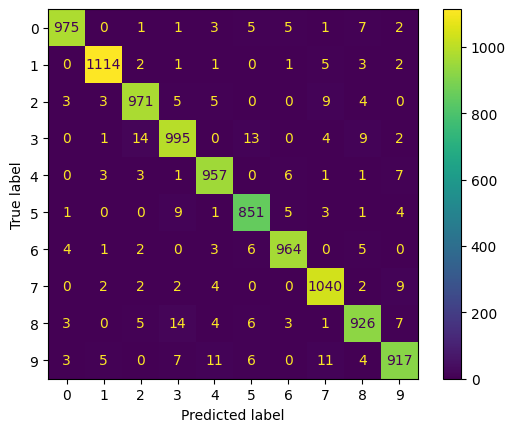

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix(y_true,y_pred)).plot()
print(classification_report(y_true, y_pred))

As we can see, the validation accuracy is very high, reaching 0.97. Precision and recall are also very good, and so is the misclassification balance.